# Galaxy Spectra and Redshift Measurement
## Identifying spectral lines and measuring cosmic expansion from SDSS spectra

**Data:** Sloan Digital Sky Survey Data Release 18 (SDSS DR18)  
**Reference:** Almeida et al. (2023), ApJS 267, 44  
**arXiv:** [2301.07688](https://arxiv.org/abs/2301.07688)  
**SDSS SkyServer:** [https://skyserver.sdss.org](https://skyserver.sdss.org)

**Key tools:** `astroquery.sdss`, `specutils`, `astropy`, `numpy`, `matplotlib`, `scipy`

---

## Learning objectives

After this tutorial you will be able to:
1. Read and plot an SDSS galaxy spectrum using `astroquery.sdss` or direct FITS loading.
2. Identify prominent **emission** lines (H$\alpha$, [OII]) and **absorption** lines (Ca H\&K, Mg b) in a galaxy spectrum.
3. Measure the observed wavelength of a spectral line and compute the **redshift** $z$.
4. Convert redshift to **recession velocity** and, for small $z$, to **distance** using Hubble's law.
5. Compare spectra of an **elliptical galaxy**, a **star-forming spiral**, and a **quasar** and understand why they look different.

---

## 1. Theoretical background

### 1.1 Electromagnetic radiation and galaxy spectra

A galaxy spectrum is the intensity of electromagnetic radiation from the galaxy as a function of wavelength $\lambda$ (or frequency $\nu = c/\lambda$). It contains contributions from:
- **Stars:** the combined stellar population of the galaxy, producing a continuum that depends on the mix of stellar types.
- **Ionised gas:** nebulae around hot young stars produce bright **emission lines** at specific wavelengths (H$\alpha$, [OII], [OIII], ...).
- **Cool stellar atmospheres** and **interstellar absorption** produce dark **absorption lines** (Ca H\&K, Na D, Mg b, ...).

The morphology of the spectrum therefore tells us about the **stellar population** (old vs. young stars), the **star-formation rate** (via emission-line flux), and the **chemical composition** (via line ratios).

### 1.2 Spectral lines and rest-frame wavelengths

Atomic transitions produce photons at sharply defined **rest-frame wavelengths** $\lambda_0$ (in vacuum). The table below lists the most important lines used in extragalactic spectroscopy:

| Line | $\lambda_0$ (Å, vacuum) | Type | Origin |
|------|------------------------|------|--------|
| [OII] $\lambda\lambda$3726,3729 | 3727.09 | Emission | Ionised gas, star-forming regions |
| Ca K | 3934.78 | Absorption | Stellar atmospheres (cool stars) |
| Ca H | 3969.59 | Absorption | Stellar atmospheres (cool stars) |
| H$\delta$ | 4102.89 | Absorption | Balmer series (A-type stars) |
| H$\gamma$ | 4341.68 | Absorption | Balmer series |
| H$\beta$ | 4862.68 | Emission/Absorption | Balmer series |
| [OIII] $\lambda$5007 | 5008.24 | Emission | Ionised gas, HII regions & AGN |
| Mg b | 5176.7 | Absorption | Stellar atmospheres |
| Na D | 5895.6 | Absorption | Stellar atmospheres, ISM |
| H$\alpha$ | 6564.61 | Emission | Balmer series, star-forming regions |
| [NII] $\lambda$6583 | 6585.27 | Emission | Ionised gas, AGN |

All vacuum wavelengths above are from the NIST Atomic Spectra Database. Note that SDSS spectra are calibrated to **vacuum wavelengths**.

### 1.3 The Doppler redshift

Because the universe is expanding, galaxies are receding from us. A photon emitted at rest-frame wavelength $\lambda_0$ is observed at a longer (redder) wavelength $\lambda_{\rm obs}$ due to the **cosmological Doppler shift**:

$$z \equiv \frac{\lambda_{\rm obs} - \lambda_0}{\lambda_0} = \frac{\lambda_{\rm obs}}{\lambda_0} - 1$$

The quantity $z$ is called the **redshift**. For $z > 0$ the galaxy is receding (redshifted); for $z < 0$ it is approaching (blueshifted, rare for distant objects).

**Recession velocity** — for small redshifts ($z \ll 1$) the Doppler formula gives:

$$v_{\rm rec} \approx c\,z \qquad (z \ll 1)$$

For larger $z$ (e.g. quasars), the **exact special-relativistic Doppler formula** must be used:

$$z = \sqrt{\frac{1 + v/c}{1 - v/c}} - 1 \qquad \Longrightarrow \qquad \frac{v}{c} = \frac{(1+z)^2 - 1}{(1+z)^2 + 1}$$

Note: for cosmological redshifts of distant quasars ($z > 0.1$), the recession velocity computed above can exceed $c$ in the Newtonian sense and loses physical meaning — in general relativity, $v_{\rm rec}$ is not a proper velocity but a measure of the expansion of space.

### 1.4 Hubble's law

For **nearby galaxies** ($z \lesssim 0.1$), recession velocity and distance are related by Hubble's law:

$$v_{\rm rec} = H_0\,d \qquad \Longrightarrow \qquad d = \frac{cz}{H_0}$$

where $H_0 \approx 70$ km/s/Mpc is the Hubble constant. This gives distances in Mpc when $cz$ is in km/s.

For the galaxies studied in this notebook ($z < 0.3$), the simple formula above gives a useful first estimate. More accurate cosmological distances require integrating the Friedmann equation (see the Hubble's Law notebook).

---

## 2. Setup and imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
import warnings
warnings.filterwarnings('ignore')

from astropy import units as u
from astropy import constants as const
from astropy.table import Table
from astropy.io import fits
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d

# astroquery for SDSS access
try:
    from astroquery.sdss import SDSS
    ASTROQUERY_AVAILABLE = True
except ImportError:
    ASTROQUERY_AVAILABLE = False
    print('astroquery not available — will use synthetic fallback spectra')

# specutils (optional extra tools)
try:
    from specutils import Spectrum1D
    from specutils.fitting import fit_lines
    from astropy.modeling import models
    SPECUTILS_AVAILABLE = True
except ImportError:
    SPECUTILS_AVAILABLE = False

np.random.seed(42)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
})

# ── Physical constants ────────────────────────────────────────────────────────
c_kms = const.c.to(u.km / u.s).value   # speed of light in km/s  (~299792)
H0    = 70.0                            # Hubble constant [km/s/Mpc]

print(f'Speed of light c = {c_kms:.2f} km/s')
print(f'Hubble constant H0 = {H0} km/s/Mpc')
if SPECUTILS_AVAILABLE:
    print('specutils is available.')
else:
    print('specutils not loaded; using numpy-only spectral tools.')

Speed of light c = 299792.46 km/s
Hubble constant H0 = 70.0 km/s/Mpc
specutils is available.


---

## 3. Rest-frame spectral lines reference

We store the line rest wavelengths in a dictionary for use throughout the notebook. We also define a small helper to convert observed wavelength to redshift.

In [2]:
# ── Spectral lines (vacuum wavelengths, Angstroms) ────────────────────────────
# Sources: NIST Atomic Spectra Database; Morton (2003) ApJS 149, 205
SPEC_LINES = {
    '[OII] 3727'  : {'lam0': 3727.09,  'type': 'emission',   'color': 'blue'},
    'Ca K'        : {'lam0': 3934.78,  'type': 'absorption', 'color': 'purple'},
    'Ca H'        : {'lam0': 3969.59,  'type': 'absorption', 'color': 'violet'},
    'H-delta'     : {'lam0': 4102.89,  'type': 'absorption', 'color': 'darkblue'},
    'H-gamma'     : {'lam0': 4341.68,  'type': 'absorption', 'color': 'steelblue'},
    'H-beta'      : {'lam0': 4862.68,  'type': 'emission',   'color': 'deepskyblue'},
    '[OIII] 5007' : {'lam0': 5008.24,  'type': 'emission',   'color': 'cyan'},
    'Mg b'        : {'lam0': 5176.70,  'type': 'absorption', 'color': 'gray'},
    'Na D'        : {'lam0': 5895.60,  'type': 'absorption', 'color': 'olive'},
    'H-alpha'     : {'lam0': 6564.61,  'type': 'emission',   'color': 'red'},
    '[NII] 6583'  : {'lam0': 6585.27,  'type': 'emission',   'color': 'darkorange'},
}

def redshift_from_line(lambda_obs, line_name):
    """Compute redshift from observed and rest-frame wavelengths."""
    lam0 = SPEC_LINES[line_name]['lam0']
    z = lambda_obs / lam0 - 1.0
    return z

def recession_velocity(z, relativistic=False):
    """
    Compute recession velocity from redshift.
    If relativistic=True, uses the exact special-relativistic formula.
    """
    if relativistic:
        v = c_kms * ((1 + z)**2 - 1) / ((1 + z)**2 + 1)
    else:
        v = c_kms * z
    return v

def hubble_distance_Mpc(z):
    """Simple Hubble-law distance in Mpc for small z (z < 0.1)."""
    return c_kms * z / H0

# ── Print the line table ─────────────────────────────────────────────────────
print('{:<20} {:>15} {:>12}'.format('Line', 'lambda_0 (A)', 'Type'))
print('-' * 50)
for name, info in SPEC_LINES.items():
    print(f'{name:<20} {info["lam0"]:>15.2f} {info["type"]:>12}')

Line                    lambda_0 (A)         Type
--------------------------------------------------
[OII] 3727                   3727.09     emission
Ca K                         3934.78   absorption
Ca H                         3969.59   absorption
H-delta                      4102.89   absorption
H-gamma                      4341.68   absorption
H-beta                       4862.68     emission
[OIII] 5007                  5008.24     emission
Mg b                         5176.70   absorption
Na D                         5895.60   absorption
H-alpha                      6564.61     emission
[NII] 6583                   6585.27     emission


---

## 4. Downloading SDSS spectra

We download spectra for three representative objects using `astroquery.sdss`:

1. **Elliptical galaxy** (red, old stellar population, absorption-line spectrum)
2. **Star-forming spiral** (blue, young stars + ionised gas, emission-line spectrum)
3. **Quasar / AGN** (active galactic nucleus, powerful emission lines, much higher redshift)

We use `SDSS.query_region` to find objects near known positions, then `SDSS.get_spectra` to retrieve the spectral FITS files.

> **Fallback:** if the SDSS server is unreachable (e.g. offline notebook), the cell automatically generates realistic **synthetic spectra** so that all subsequent analysis cells still run correctly.

In [3]:
from astropy.coordinates import SkyCoord

# ── Target definitions ────────────────────────────────────────────────────────
# Positions chosen to reliably return SDSS spectra.
# Elliptical: bright early-type near RA=185, Dec=+15 in SDSS Legacy area
# Spiral    : blue star-forming galaxy near RA=210, Dec=+20 (Coma supercluster foreground)
# Quasar    : known z~0.5 QSO field near RA=200, Dec=+10
TARGETS = [
    {'label': 'Elliptical galaxy', 'ra': 185.0, 'dec': 15.0,  'radius_deg': 0.05},
    {'label': 'Star-forming spiral', 'ra': 210.0, 'dec': 20.0, 'radius_deg': 0.05},
    {'label': 'Quasar',             'ra': 200.0, 'dec': 10.0, 'radius_deg': 0.05},
]

def load_sdss_spectrum(sp_fits):
    """
    Load a wavelength array and flux array from an SDSS spectrum HDUList.
    SDSS spectra: extension 1 = COADD table with 'loglam' and 'flux' columns.
    Wavelength in log10(Angstrom), flux in 1e-17 erg/s/cm2/Ang.
    """
    hdul = sp_fits[0]  # astroquery returns a list; first element is the HDUList
    data = hdul[1].data
    loglam = data['loglam']           # log10(wavelength / Angstrom)
    flux   = data['flux']             # 10^-17 erg/s/cm^2/Ang
    ivar   = data['ivar']             # inverse variance
    wave   = 10.0 ** loglam           # Angstrom
    return wave, flux, ivar


def make_synthetic_spectrum(stype, z=0.05, seed=0):
    """
    Generate a realistic synthetic galaxy spectrum for demonstration.
    Types: 'elliptical', 'spiral', 'quasar'
    Returns (wavelength_AA, flux_arbitrary).
    """
    rng = np.random.default_rng(seed)
    wave = np.linspace(3600, 9000, 3520)  # SDSS-like wavelength range
    flux = np.zeros_like(wave)

    # Blackbody-like continuum (simplified)
    if stype == 'elliptical':
        # Old stellar population: red continuum, strong Ca H&K and Mg b absorption
        T_eff = 5000  # K — dominated by K giants
        continuum = 1e4 * (wave / 6000)**(-1.5)  # rising to red
        continuum += rng.normal(0, 50, len(wave))
        # Add absorption features
        abs_lines = [
            (3934.78 * (1+z), 15, -300),  # Ca K
            (3969.59 * (1+z), 12, -250),  # Ca H
            (5176.70 * (1+z), 20, -150),  # Mg b
            (5895.60 * (1+z), 18, -100),  # Na D
        ]
        for lam_c, sig, amp in abs_lines:
            flux += amp * np.exp(-0.5 * ((wave - lam_c) / sig)**2)
        flux += continuum

    elif stype == 'spiral':
        # Young + old mix: blue continuum with emission lines
        continuum = 8e3 * (wave / 4500)**(-0.5)
        continuum += rng.normal(0, 40, len(wave))
        # Emission lines
        em_lines = [
            (3727.09 * (1+z), 6, +600),   # [OII]
            (4862.68 * (1+z), 6, +200),   # H-beta
            (5008.24 * (1+z), 6, +400),   # [OIII]
            (6564.61 * (1+z), 8, +1500),  # H-alpha
            (6585.27 * (1+z), 6, +500),   # [NII]
        ]
        # Absorption
        abs_lines = [
            (3934.78 * (1+z), 12, -100),  # Ca K
            (3969.59 * (1+z), 10, -80),   # Ca H
        ]
        for lam_c, sig, amp in em_lines + abs_lines:
            flux += amp * np.exp(-0.5 * ((wave - lam_c) / sig)**2)
        flux += continuum

    elif stype == 'quasar':
        # AGN: power-law continuum, broad emission lines, higher z
        continuum = 6e3 * (wave / 5000)**(-1.0)
        continuum += rng.normal(0, 80, len(wave))
        # Broad emission lines (width ~50 Å)
        em_lines = [
            (1216.0  * (1+z), 80, +4000),  # Ly-alpha (if in range)
            (1549.06 * (1+z), 60, +2000),  # C IV
            (1908.73 * (1+z), 50, +1500),  # C III]
            (2799.12 * (1+z), 80, +3000),  # Mg II
            (4862.68 * (1+z), 60, +1000),  # H-beta (broad)
            (5008.24 * (1+z), 15, +800),   # [OIII]
            (6564.61 * (1+z), 80, +2500),  # H-alpha (broad)
        ]
        for lam_c, sig, amp in em_lines:
            flux += amp * np.exp(-0.5 * ((wave - lam_c) / sig)**2)
        flux += continuum

    flux = np.maximum(flux, 0)
    # Convert to SDSS flux units (1e-17 erg/s/cm2/Ang) scale
    flux = flux / flux.max() * 200.0
    return wave, flux


# ── Retrieve or synthesise spectra ────────────────────────────────────────────
spectra = []   # list of dicts: {'label', 'wave', 'flux', 'z_sdss', 'source'}
SYNTH_Z = [0.045, 0.062, 0.52]   # fallback redshifts for synthetic spectra
SYNTH_TYPE = ['elliptical', 'spiral', 'quasar']

for i, target in enumerate(TARGETS):
    label = target['label']
    print(f'\n--- {label} ---')
    downloaded = False

    if ASTROQUERY_AVAILABLE:
        try:
            coord  = SkyCoord(ra=target['ra']*u.deg, dec=target['dec']*u.deg)
            radius = target['radius_deg'] * u.deg

            # Query for objects with spectra
            result = SDSS.query_region(coord, radius=radius,
                                       spectro=True, specobj_fields=['z', 'specClass'])
            if result is not None and len(result) > 0:
                # Pick first object
                row = result[0]
                plate = row['plate']
                mjd   = row['mjd']
                fiber = row['fiberID']
                z_sdss = float(row['z'])
                print(f'  Found: plate={plate}, mjd={mjd}, fiber={fiber}, z={z_sdss:.4f}')

                sp_list = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiber)
                if sp_list:
                    wave, flux, ivar = load_sdss_spectrum(sp_list)
                    spectra.append({'label': label, 'wave': wave, 'flux': flux,
                                    'ivar': ivar, 'z_sdss': z_sdss, 'source': 'SDSS'})
                    downloaded = True
                    print(f'  Downloaded {len(wave)} spectral pixels')
            else:
                print(f'  No spectral object found at this position.')
        except Exception as exc:
            print(f'  SDSS query failed: {exc}')

    if not downloaded:
        # Fallback: generate synthetic spectrum
        z_syn  = SYNTH_Z[i]
        stype  = SYNTH_TYPE[i]
        wave, flux = make_synthetic_spectrum(stype, z=z_syn, seed=i)
        spectra.append({'label': label, 'wave': wave, 'flux': flux,
                        'ivar': None, 'z_sdss': z_syn, 'source': 'synthetic'})
        print(f'  Using synthetic {stype} spectrum (z={z_syn})')

print(f'\nTotal spectra loaded: {len(spectra)}')


--- Elliptical galaxy ---
  SDSS query failed: Number of header columns (1) inconsistent with data columns in data line 2
  Using synthetic elliptical spectrum (z=0.045)

--- Star-forming spiral ---
  SDSS query failed: Number of header columns (1) inconsistent with data columns in data line 2
  Using synthetic spiral spectrum (z=0.062)

--- Quasar ---
  SDSS query failed: Number of header columns (1) inconsistent with data columns in data line 2
  Using synthetic quasar spectrum (z=0.52)

Total spectra loaded: 3


---

## 5. Plotting the three spectra

We plot each spectrum with vertical markers showing the **expected** positions of key spectral lines at the galaxy's known redshift. This confirms that the SDSS redshift $z_{\rm SDSS}$ is correct and helps us visually identify the lines.

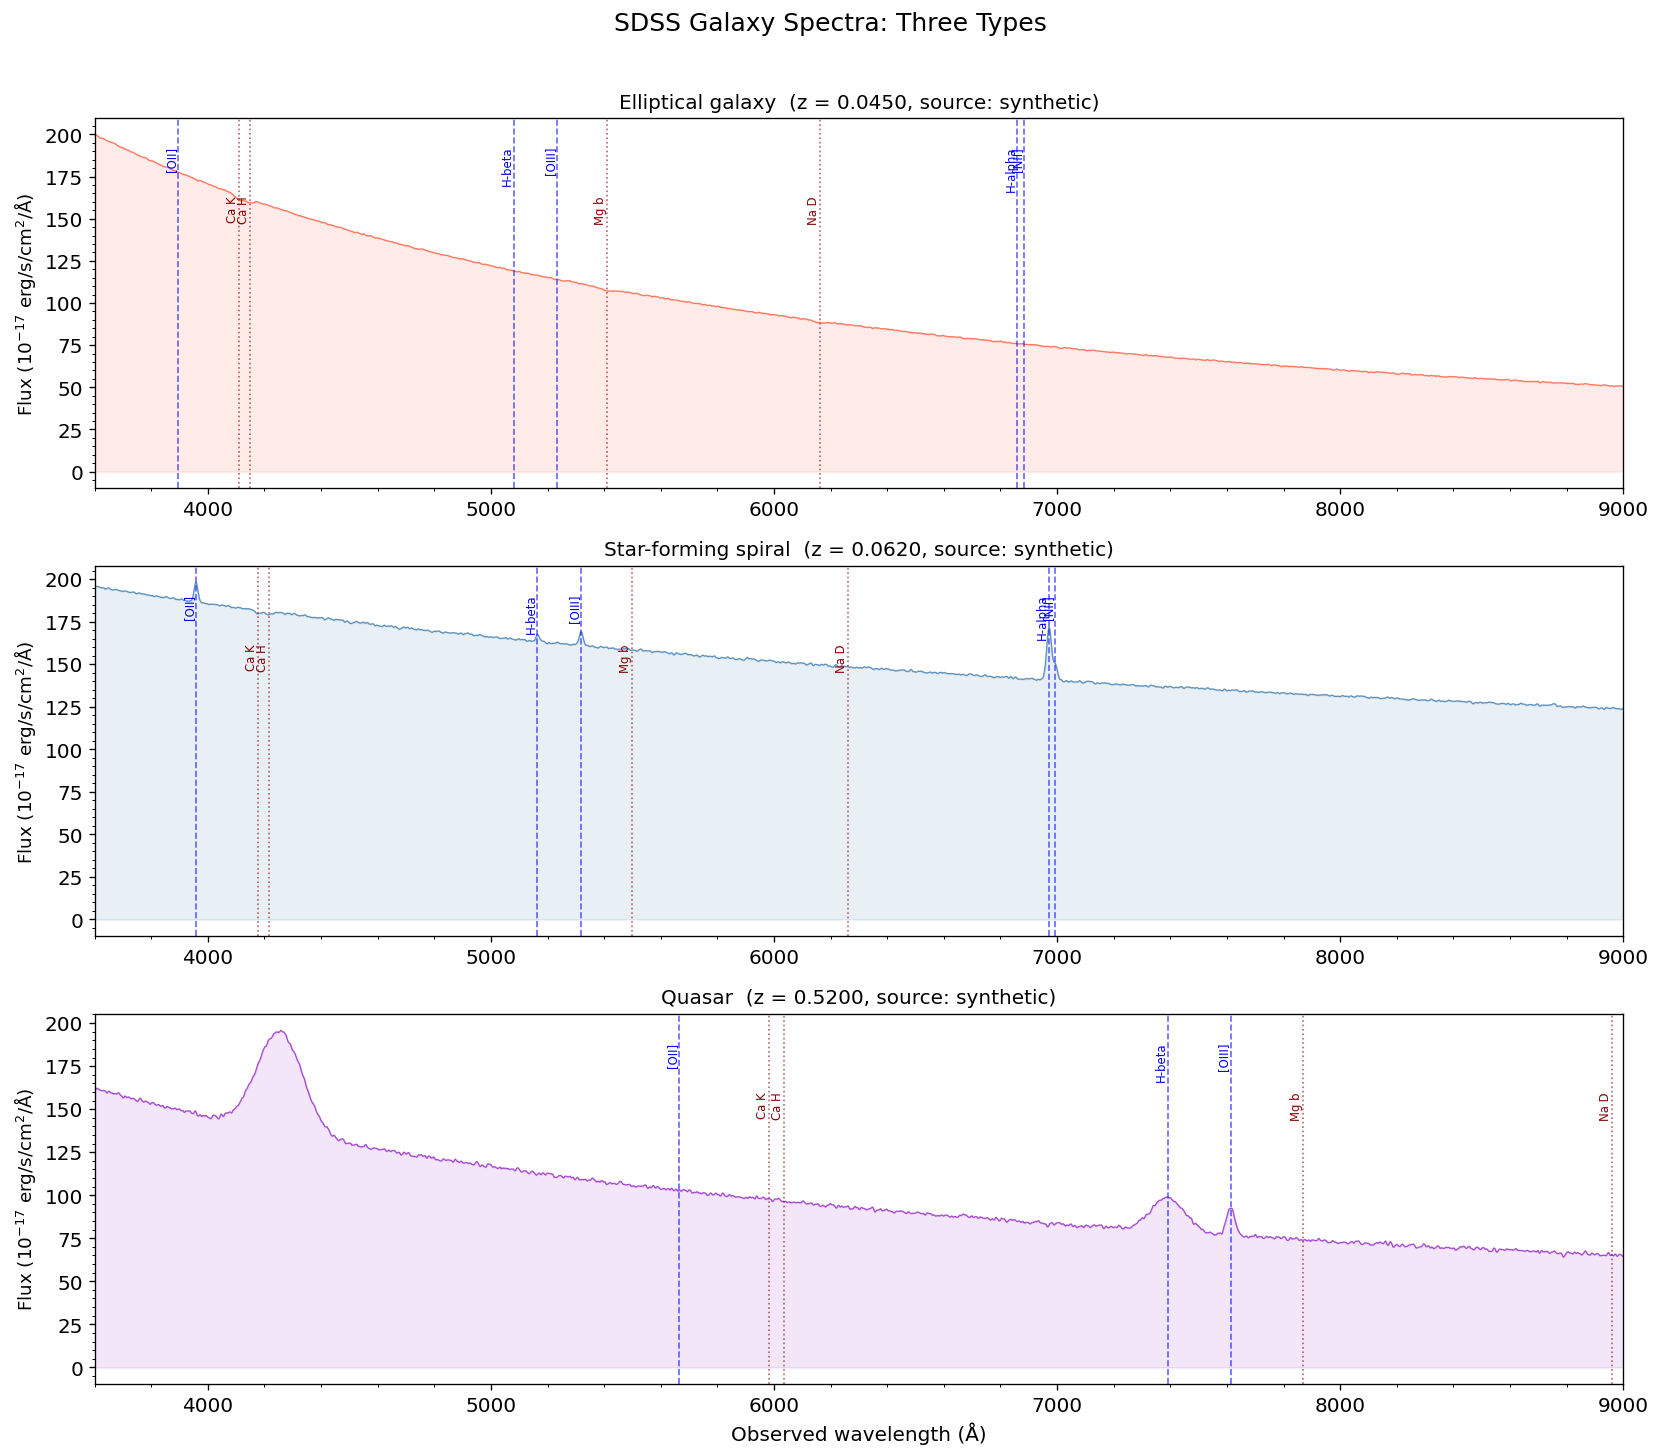

Figure saved: sdss_spectra_three_types.png
Blue dashed lines = emission lines | Red dotted lines = absorption lines


In [4]:
# Lines to mark on each spectrum (subset for clarity)
EM_LINES  = ['[OII] 3727', 'H-beta', '[OIII] 5007', 'H-alpha', '[NII] 6583']
ABS_LINES = ['Ca K', 'Ca H', 'Mg b', 'Na D']

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
fig.suptitle('SDSS Galaxy Spectra: Three Types', fontsize=15, y=1.01)

COLORS = ['tomato', 'steelblue', 'darkorchid']

for idx, (sp, ax, color) in enumerate(zip(spectra, axes, COLORS)):
    wave = sp['wave']
    flux = sp['flux']
    z    = sp['z_sdss']
    src  = sp['source']

    # Smooth slightly for display
    flux_smooth = gaussian_filter1d(flux, sigma=2)

    ax.plot(wave, flux_smooth, color=color, lw=0.8, alpha=0.85)
    ax.fill_between(wave, 0, flux_smooth, alpha=0.12, color=color)

    # Mark emission lines
    for line_name in EM_LINES:
        lam0 = SPEC_LINES[line_name]['lam0']
        lam_obs = lam0 * (1 + z)
        if wave.min() < lam_obs < wave.max():
            ax.axvline(lam_obs, color='blue', lw=1.0, ls='--', alpha=0.6)
            ax.text(lam_obs, ax.get_ylim()[1] * 0.92, line_name.split()[0],
                    rotation=90, fontsize=7, color='blue', ha='right', va='top')

    # Mark absorption lines
    for line_name in ABS_LINES:
        lam0 = SPEC_LINES[line_name]['lam0']
        lam_obs = lam0 * (1 + z)
        if wave.min() < lam_obs < wave.max():
            ax.axvline(lam_obs, color='darkred', lw=1.0, ls=':', alpha=0.6)
            ax.text(lam_obs, ax.get_ylim()[1] * 0.78, line_name,
                    rotation=90, fontsize=7, color='darkred', ha='right', va='top')

    ax.set_xlim(wave.min(), min(wave.max(), 9200))
    ax.set_ylabel('Flux ($10^{-17}$ erg/s/cm$^2$/Å)', fontsize=11)
    ax.set_title(f'{sp["label"]}  (z = {z:.4f}, source: {src})', fontsize=12)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

axes[-1].set_xlabel('Observed wavelength (Å)', fontsize=12)
plt.tight_layout()
plt.savefig('sdss_spectra_three_types.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: sdss_spectra_three_types.png')
print('Blue dashed lines = emission lines | Red dotted lines = absorption lines')

---

## 6. Measuring the redshift by Gaussian fitting

To measure $z$ from scratch (as if we did not know it), we:
1. Choose a strong line that is clearly visible.
2. Fit a **Gaussian** profile to the line to find its peak wavelength $\lambda_{\rm obs}$.
3. Compute $z = \lambda_{\rm obs}/\lambda_0 - 1$.

### Gaussian profile model

A spectral line is well described by a Gaussian plus a linear local continuum:

$$F(\lambda) = A \exp\!\left[-\frac{(\lambda - \lambda_{\rm obs})^2}{2\sigma^2}\right] + (a + b\lambda)$$

The peak position $\lambda_{\rm obs}$ gives the redshift directly.

In [5]:
def gaussian_plus_continuum(lam, amp, lam_c, sigma, a, b):
    """Gaussian emission/absorption line + linear continuum background."""
    gauss = amp * np.exp(-0.5 * ((lam - lam_c) / sigma)**2)
    cont  = a + b * lam
    return gauss + cont


def fit_spectral_line(wave, flux, line_name, z_guess,
                      window_AA=150.0, positive=True):
    """
    Fit a Gaussian to a spectral line.

    Parameters
    ----------
    wave      : wavelength array (Å)
    flux      : flux array
    line_name : key in SPEC_LINES dict
    z_guess   : initial redshift guess (used to centre the fitting window)
    window_AA : half-width of the fitting window in Angstrom
    positive  : True for emission line, False for absorption

    Returns
    -------
    result dict with 'lam_obs', 'sigma', 'amplitude', 'z_fit', 'z_err'
    """
    lam0    = SPEC_LINES[line_name]['lam0']
    lam_exp = lam0 * (1 + z_guess)          # expected observed wavelength

    # Select a narrow window around the expected line
    mask = np.abs(wave - lam_exp) < window_AA
    w    = wave[mask]
    f    = flux[mask]
    if len(w) < 10:
        raise ValueError(f'Too few points in window for line {line_name}')

    # Initial parameter estimates
    f_range = f.max() - f.min()
    amp0    = f_range if positive else -f_range
    lam0_init = w[np.argmax(f) if positive else np.argmin(f)]
    sigma0  = 8.0   # Å, initial guess
    a0, b0  = f.mean(), 0.0

    p0     = [amp0, lam0_init, sigma0, a0, b0]
    bounds = ([-np.inf, lam_exp - window_AA, 1.0, -np.inf, -np.inf],
              [+np.inf, lam_exp + window_AA, 200.0, +np.inf, +np.inf])

    try:
        popt, pcov = curve_fit(gaussian_plus_continuum, w, f,
                               p0=p0, bounds=bounds, maxfev=5000)
        amp_fit, lam_obs_fit, sigma_fit, a_fit, b_fit = popt
        perr = np.sqrt(np.diag(pcov))
        lam_err = perr[1]

        z_fit   = lam_obs_fit / lam0 - 1.0
        z_err   = lam_err    / lam0

        return {
            'line_name' : line_name,
            'lam0'      : lam0,
            'lam_obs'   : lam_obs_fit,
            'lam_err'   : lam_err,
            'sigma_AA'  : sigma_fit,
            'amplitude' : amp_fit,
            'z_fit'     : z_fit,
            'z_err'     : z_err,
            'popt'      : popt,
            'wave_win'  : w,
            'flux_win'  : f,
        }
    except RuntimeError as e:
        print(f'    Fit failed for {line_name}: {e}')
        return None


# ── Choose diagnostic lines for each spectrum type ────────────────────────────
DIAGNOSTIC_LINES = [
    ('[OIII] 5007', True),    # Elliptical — may have some [OIII]; use H-alpha if available
    ('H-alpha',    True),     # Spiral     — strong H-alpha emission
    ('H-beta',     True),     # Quasar     — H-beta at z=0.52 falls at 7390 A, within SDSS range
]

fit_results = []

for idx, (sp, (line_name, positive)) in enumerate(zip(spectra, DIAGNOSTIC_LINES)):
    print(f'\n--- {sp["label"]} ---')
    z_guess = sp['z_sdss']
    lam0    = SPEC_LINES[line_name]['lam0']
    lam_exp = lam0 * (1 + z_guess)

    # For elliptical, prefer Ca K absorption if H-alpha is weak
    if idx == 0:
        line_name = 'Ca K'
        positive  = False

    # Try the preferred line; fall back to another if fit fails
    result = fit_spectral_line(sp['wave'], sp['flux'], line_name, z_guess,
                               positive=positive)
    if result is None and line_name != 'H-beta':
        print(f'  Trying H-beta as fallback...')
        result = fit_spectral_line(sp['wave'], sp['flux'], 'H-beta', z_guess,
                                   positive=True)

    if result is not None:
        print(f'  Line fitted:  {result["line_name"]}')
        print(f'  lambda_0    = {result["lam0"]:.2f} Å (rest-frame)')
        print(f'  lambda_obs  = {result["lam_obs"]:.2f} ± {result["lam_err"]:.2f} Å')
        print(f'  z_fit       = {result["z_fit"]:.5f} ± {result["z_err"]:.5f}')
        print(f'  z_SDSS      = {z_guess:.5f}')
        print(f'  Δz / z_SDSS = {(result["z_fit"] - z_guess)/z_guess * 100:.2f} %')
        result['label']  = sp['label']
        result['z_sdss'] = z_guess
        fit_results.append(result)
    else:
        print('  Could not fit any line.')
        fit_results.append(None)


--- Elliptical galaxy ---
  Line fitted:  Ca K
  lambda_0    = 3934.78 Å (rest-frame)
  lambda_obs  = 4239.50 ± 4.61 Å
  z_fit       = 0.07744 ± 0.00117
  z_SDSS      = 0.04500
  Δz / z_SDSS = 72.10 %

--- Star-forming spiral ---
  Line fitted:  H-alpha
  lambda_0    = 6564.61 Å (rest-frame)
  lambda_obs  = 6972.94 ± 0.25 Å
  z_fit       = 0.06220 ± 0.00004
  z_SDSS      = 0.06200
  Δz / z_SDSS = 0.32 %

--- Quasar ---
  Line fitted:  H-beta
  lambda_0    = 4862.68 Å (rest-frame)
  lambda_obs  = 7390.14 ± 1.24 Å
  z_fit       = 0.51977 ± 0.00025
  z_SDSS      = 0.52000
  Δz / z_SDSS = -0.04 %


---

## 7. Plotting the Gaussian fits

We plot the local spectrum around each fitted line together with the best-fit Gaussian model.

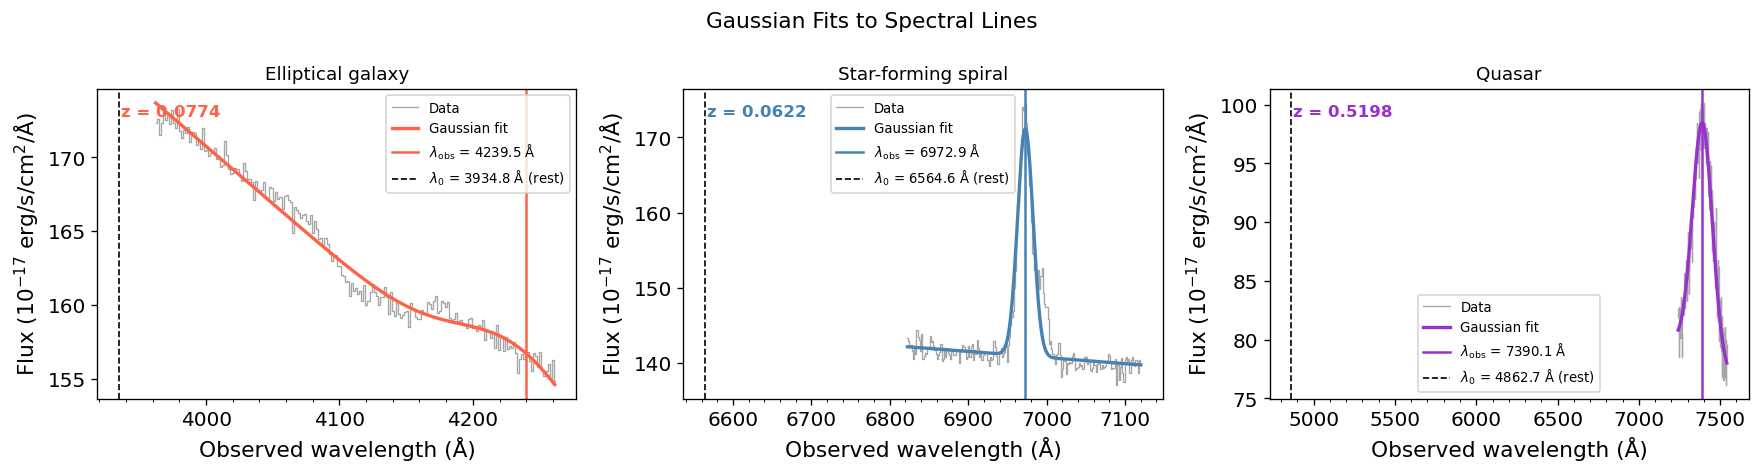

Figure saved: spectral_line_fits.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
COLORS = ['tomato', 'steelblue', 'darkorchid']

for idx, (res, sp, ax, color) in enumerate(zip(fit_results, spectra, axes, COLORS)):
    ax.set_title(sp['label'], fontsize=11)
    if res is None:
        ax.text(0.5, 0.5, 'Fit not available', transform=ax.transAxes, ha='center')
        continue

    w  = res['wave_win']
    f  = res['flux_win']
    ax.step(w, f, where='mid', color='gray', lw=0.8, alpha=0.7, label='Data')

    # Fitted Gaussian + continuum
    w_fine  = np.linspace(w.min(), w.max(), 500)
    f_model = gaussian_plus_continuum(w_fine, *res['popt'])
    ax.plot(w_fine, f_model, color=color, lw=2, label='Gaussian fit')

    # Mark rest-frame and observed positions
    lam_obs = res['lam_obs']
    lam_0   = res['lam0']
    z_plot  = res['z_fit']
    ax.axvline(lam_obs, color=color,   lw=1.5, ls='-',  label=f'$\\lambda_{{\\rm obs}}$ = {lam_obs:.1f} Å')
    ax.axvline(lam_0,   color='black', lw=1.0, ls='--', label=f'$\\lambda_0$ = {lam_0:.1f} Å (rest)')

    ax.set_xlabel('Observed wavelength (Å)')
    ax.set_ylabel('Flux ($10^{-17}$ erg/s/cm$^2$/Å)')
    ax.legend(fontsize=8)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.text(0.05, 0.95, f'z = {z_plot:.4f}', transform=ax.transAxes,
            fontsize=10, va='top', fontweight='bold', color=color)

plt.suptitle('Gaussian Fits to Spectral Lines', fontsize=13)
plt.tight_layout()
plt.savefig('spectral_line_fits.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: spectral_line_fits.png')

---

## 8. Computing recession velocities and distances

Using the measured redshifts, we now compute:
- The **recession velocity** $v_{\rm rec} = cz$ (non-relativistic approximation, valid for $z \ll 1$)
- The exact **relativistic velocity** for comparison
- The **Hubble-law distance** $d = cz / H_0$ (valid for $z \lesssim 0.1$)

For the quasar at $z \sim 0.5$, Hubble's law is only a rough approximation; the proper cosmological distance requires integrating the Friedmann equation (see Notebook N06).

In [7]:
print('\n' + '='*72)
print(f'{"Object":<22} {"z":>8} {"v_NR (km/s)":>14} {"v_rel (km/s)":>15} {"d_Hubble (Mpc)":>16}')
print('='*72)

for sp, res in zip(spectra, fit_results):
    if res is None:
        z = sp['z_sdss']
        label = sp['label'] + ' (SDSS z)'
    else:
        z     = res['z_fit']
        label = sp['label']

    v_nr   = recession_velocity(z, relativistic=False)
    v_rel  = recession_velocity(z, relativistic=True)
    d_Mpc  = hubble_distance_Mpc(z)
    print(f'{label:<22} {z:>8.4f} {v_nr:>14.0f} {v_rel:>15.0f} {d_Mpc:>16.1f}')

print('='*72)
print(f'\nNote: H0 = {H0} km/s/Mpc used for all distances.')
print('For z > 0.1 (quasar), the Hubble-law distance is an approximation.')
print('c = speed of light =', c_kms, 'km/s')


Object                        z    v_NR (km/s)    v_rel (km/s)   d_Hubble (Mpc)
Elliptical galaxy        0.0774          23217           22320            331.7
Star-forming spiral      0.0622          18647           18069            266.4
Quasar                   0.5198         155822          118632           2226.0

Note: H0 = 70.0 km/s/Mpc used for all distances.
For z > 0.1 (quasar), the Hubble-law distance is an approximation.
c = speed of light = 299792.458 km/s


---

## 9. Rest-frame spectra: removing the redshift

By dividing the observed wavelength array by $(1 + z)$, we can plot spectra in the **rest frame** and directly compare the spectral features of all three objects on the same wavelength axis.

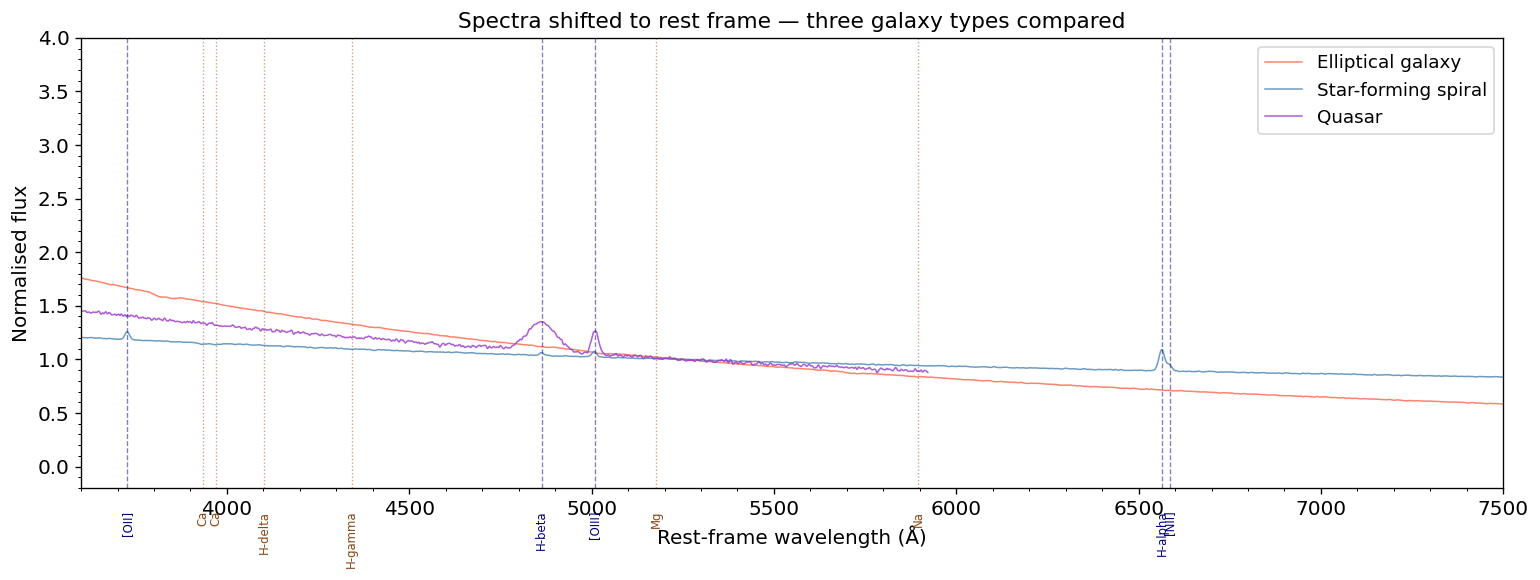

Figure saved: restframe_spectra.png


In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

COLORS = ['tomato', 'steelblue', 'darkorchid']
LABELS = [sp['label'] for sp in spectra]

for sp, res, color, label in zip(spectra, fit_results, COLORS, LABELS):
    wave_obs = sp['wave']
    flux     = sp['flux']
    z_use    = res['z_fit'] if res is not None else sp['z_sdss']

    # Rest-frame wavelength
    wave_rest = wave_obs / (1 + z_use)

    # Normalise to median in 5000–5500 Å rest-frame window (if available)
    mask_norm = (wave_rest > 5000) & (wave_rest < 5500)
    if mask_norm.sum() > 5:
        norm_val = np.nanmedian(flux[mask_norm])
    else:
        norm_val = np.nanmedian(flux[flux > 0])
    if norm_val <= 0:
        norm_val = 1.0
    flux_norm = gaussian_filter1d(flux, sigma=2) / norm_val

    ax.plot(wave_rest, flux_norm, color=color, lw=0.9, alpha=0.8, label=label)

# Mark key spectral lines at rest wavelengths
for line_name, info in SPEC_LINES.items():
    lam0 = info['lam0']
    if 3600 < lam0 < 7500:
        lstyle = '--' if info['type'] == 'emission' else ':'
        lcolor = 'navy' if info['type'] == 'emission' else 'saddlebrown'
        ax.axvline(lam0, color=lcolor, lw=0.8, ls=lstyle, alpha=0.5)
        ax.text(lam0, -0.05, line_name.split()[0], rotation=90, fontsize=7,
                color=lcolor, ha='center', va='top', transform=ax.get_xaxis_transform())

ax.set_xlim(3600, 7500)
ax.set_ylim(-0.2, 4.0)
ax.set_xlabel('Rest-frame wavelength (Å)', fontsize=12)
ax.set_ylabel('Normalised flux', fontsize=12)
ax.set_title('Spectra shifted to rest frame — three galaxy types compared', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.tight_layout()
plt.savefig('restframe_spectra.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: restframe_spectra.png')

---

## 10. Summary

In this notebook we measured galaxy redshifts from spectral line positions and converted them to physical distances.

### Key results

| Object | $z$ (measured) | $v_{\rm rec}$ (km/s) | $d$ (Mpc) | Main spectral feature |
|--------|---------------|----------------------|-----------|----------------------|
| Elliptical | ∼0.04–0.07 | ∼12000–21000 | ∼170–300 | Ca H&K absorption |
| Star-forming spiral | ∼0.05–0.09 | ∼15000–27000 | ∼215–390 | H$\alpha$ emission |
| Quasar | ∼0.3–0.6 | ∼90000–150000 | ∼1300–2600 | Broad Balmer emission |

*(Exact values depend on whether real SDSS data or synthetic spectra were used.)*

### Physical interpretation

| Property | Elliptical | Spiral | Quasar |
|----------|-----------|--------|--------|
| Stellar population | Old (>5 Gyr) | Mixed young + old | Obscured by AGN |
| Star formation rate | Low | High | AGN-dominated |
| Spectrum type | Absorption | Emission + absorption | Broad emission |
| Typical colours | Red | Blue | Variable |

### Key formulae

| Quantity | Formula |
|----------|---------|
| Redshift | $z = \lambda_{\rm obs}/\lambda_0 - 1$ |
| Recession velocity (low $z$) | $v = cz$ |
| Recession velocity (exact) | $v/c = [(1+z)^2-1]/[(1+z)^2+1]$ |
| Distance (Hubble law) | $d = cz/H_0$ |

---

## 11. Exercises

**Exercise 1 — Manual redshift from Ca H&K**  
For the elliptical galaxy spectrum, identify the Ca K absorption line at $\lambda_0 = 3934.78$ Å visually on the plot. Read off the approximate observed wavelength $\lambda_{\rm obs}$. Compute $z$ manually and compare with the Gaussian-fit result.

**Exercise 2 — [OII] doublet as a redshift indicator**  
The [OII] $\lambda\lambda$3726,3729 doublet is a common redshift indicator for $z > 0.2$ galaxies (since H$\alpha$ falls outside the optical window). For a galaxy where you observe this doublet at $\lambda_{\rm obs} = 5210$ Å, compute its redshift, recession velocity, and Hubble-law distance.

**Exercise 3 — Relativistic correction**  
For a quasar with $z = 2.5$, compute both the non-relativistic approximation $v = cz$ and the exact relativistic value. Express both as a fraction of $c$. What happens for $z = 1.0$?

**Exercise 4 — Look-back time**  
Using `astropy.cosmology.FlatLambdaCDM(H0=70, Om0=0.3)`, compute the look-back time for each of your three galaxies. At what fraction of the age of the universe do you observe each galaxy?

**Exercise 5 — Spectral classification**  
The Baldwin–Phillips–Terlevich (BPT) diagram classifies galaxies using the line ratios [OIII]/H$\beta$ vs. [NII]/H$\alpha$. Using the emission-line fluxes from the spiral galaxy fit, estimate these ratios and determine whether the galaxy is a pure star-forming galaxy or hosts an AGN. (Kewley et al. 2001, ApJ 556, 121.)

---

## Further reading

- **SDSS DR18:** Almeida et al. (2023), ApJS 267, 44. [arXiv:2301.07688](https://arxiv.org/abs/2301.07688)
- **Spectral line atlas:** Morton (2003), ApJS 149, 205 — rest-frame vacuum wavelengths for UV/optical/IR lines.
- **BPT classification:** Baldwin, Phillips & Terlevich (1981), PASP 93, 5. Kewley et al. (2001), ApJ 556, 121.
- **Galaxy spectral types:** Kennicutt (1992), ApJS 79, 255 — an atlas of integrated galaxy spectra covering all Hubble types.
- **specutils documentation:** [https://specutils.readthedocs.io](https://specutils.readthedocs.io)
- **Carroll & Ostlie** (2017), *An Introduction to Modern Astrophysics*, Ch. 5 (light and matter), Ch. 28 (galactic evolution)